# Visualisasi Perbandingan Biaya Komunikasi: Baseline vs Quantization

Notebook ini digunakan untuk membuat grafik perbandingan biaya komunikasi (dalam GB) antara metode Baseline (tanpa kuantisasi) dan metode Kuantisasi pada berbagai konfigurasi Federated Learning (E: Local Epochs, B: Batch Size).

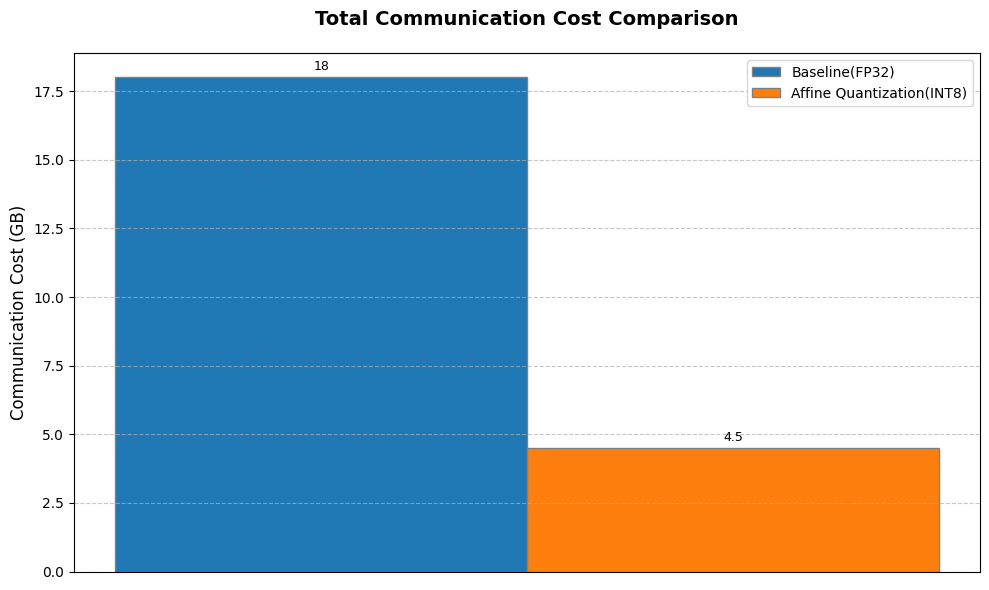

In [15]:
import matplotlib.pyplot as plt
import numpy as np

baseline_cost = [18]
quantization_cost = [4.5]

x = np.arange(len(baseline_cost))
width = 0.35

fig, ax = plt.subplots(figsize=(10, 6))

rects1 = ax.bar(x - width/2, baseline_cost, width, label='Baseline(FP32)',
                color='#1f77b4', edgecolor='grey')
rects2 = ax.bar(x + width/2, quantization_cost, width, label='Affine Quantization(INT8)',
                color='#ff7f0e', edgecolor='grey')

ax.set_ylabel('Communication Cost (GB)', fontsize=12)
ax.set_title('Total Communication Cost Comparison',
             fontsize=14, fontweight='bold', pad=20)

ax.set_xticks([])  # kosongkan label sumbu x

ax.legend()
ax.grid(axis='y', linestyle='--', alpha=0.7)

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height}',
                    xy=(rect.get_x() + rect.get_width()/2, height),
                    xytext=(0, 3),
                    textcoords="offset points",
                    ha='center', va='bottom', fontsize=9)

autolabel(rects1)
autolabel(rects2)

plt.tight_layout()
plt.show()

# Visualisasi Akurasi per Ronde: Baseline

Grafik ini menunjukkan perkembangan akurasi model selama ronde komunikasi (0-300) untuk berbagai konfigurasi Baseline.

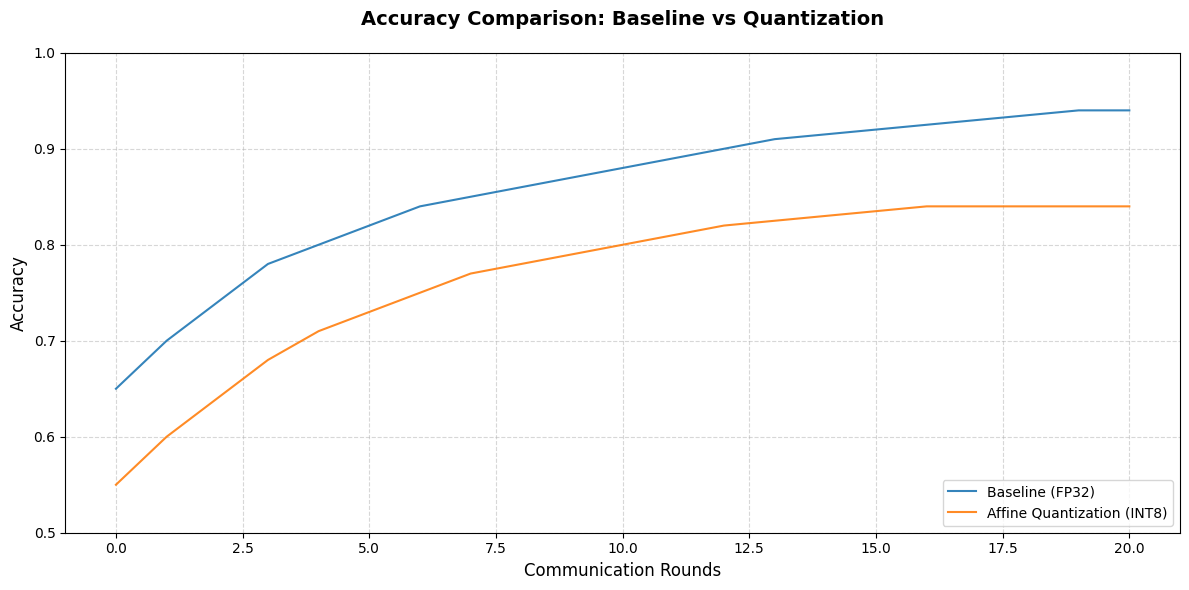

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Definisi Data Dummy Akurasi
rounds = np.arange(0, 21, 1)
configs = [
    "Baseline(FP32)",
    "Affine Quantization(INT8)"
]

# Data akurasi untuk setiap konfigurasi
accuracies = [94, 84]

# 2. Plotting
plt.figure(figsize=(12, 6))

colors = ['#1f77b4', '#ff7f0e']

for i, acc in enumerate(accuracies):
    plt.plot(rounds, acc, label=configs[i], color=colors[i], alpha=0.9)

plt.xlabel('Communication Rounds', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)
plt.title('Accuracy Comparison: Baseline vs Quantization', fontsize=14, fontweight='bold', pad=20)
plt.legend(loc='lower right', frameon=True, edgecolor='grey', fontsize=10)
plt.grid(True, linestyle='--', alpha=0.5)
plt.ylim(-0.02, 1.0)

plt.tight_layout()
plt.show()

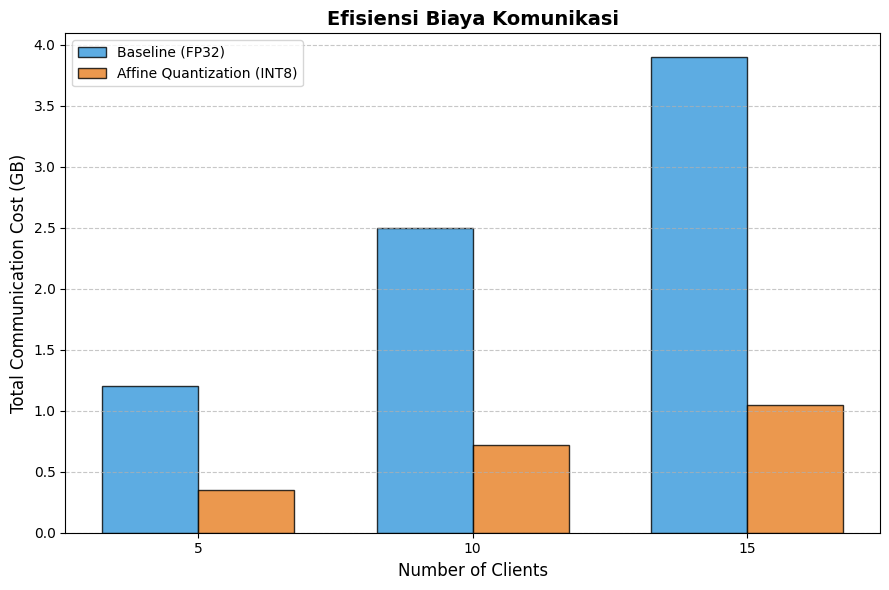

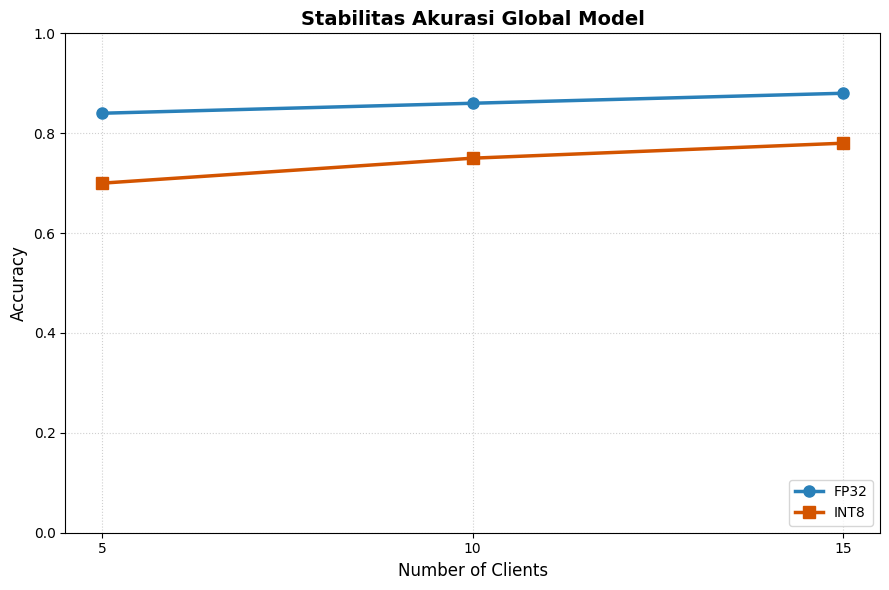

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ============================================
# DATA SIMULASI
# ============================================
clients = [5, 10, 15]
x = np.arange(len(clients))  # Lokasi label pada sumbu x
width = 0.35                 # Lebar bar

# Data Biaya Komunikasi
comm_fp32 = [1.2, 2.5, 3.9]
comm_int8 = [0.35, 0.72, 1.05]

# Data Akurasi
acc_fp32 = [0.84, 0.86, 0.88]
acc_int8 = [0.70, 0.75, 0.78]

# ============================================
# GRAFIK 1: Efisiensi Biaya Komunikasi (BAR CHART)
# ============================================
plt.figure(figsize=(9, 6))

plt.bar(x - width/2, comm_fp32, width, label='Baseline (FP32)', color='#3498db', edgecolor='black', alpha=0.8)
plt.bar(x + width/2, comm_int8, width, label='Affine Quantization (INT8)', color='#e67e22', edgecolor='black', alpha=0.8)

plt.title('Efisiensi Biaya Komunikasi', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clients', fontsize=12)
plt.ylabel('Total Communication Cost (GB)', fontsize=12)

plt.xticks(x, clients) # Mengganti indeks 0,1,2 menjadi 5,10,15
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.legend()

plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 6))

plt.plot(clients, acc_fp32, marker='o', markersize=8, linewidth=2.5, label='FP32', color='#2980b9')
plt.plot(clients, acc_int8, marker='s', markersize=8, linewidth=2.5, label='INT8', color='#d35400')

plt.title('Stabilitas Akurasi Global Model', fontsize=14, fontweight='bold')
plt.xlabel('Number of Clients', fontsize=12)
plt.ylabel('Accuracy', fontsize=12)

plt.xticks(clients)
plt.ylim(0, 1.0) # Akurasi biasanya 0-1
plt.grid(True, linestyle=':', alpha=0.6)
plt.legend(loc='lower right')

plt.tight_layout()
plt.show()